In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 224

def crop_image_from_gray(img,tol=7):
    if img.ndim ==2:
        mask = img>tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    elif img.ndim==3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img>tol
        
        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0): # image is too dark so that we crop out everything,
            return img # return original image
        else:
            img1=img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2=img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3=img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
    #         print(img1.shape,img2.shape,img3.shape)
            img = np.stack([img1,img2,img3],axis=-1)
    #         print(img.shape)
        return img
        
def load_ben_color(path, sigmaX):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image=cv2.addWeighted( image,4, cv2.GaussianBlur( image , (0,0) , sigmaX) ,-4 ,128)
        
    return image

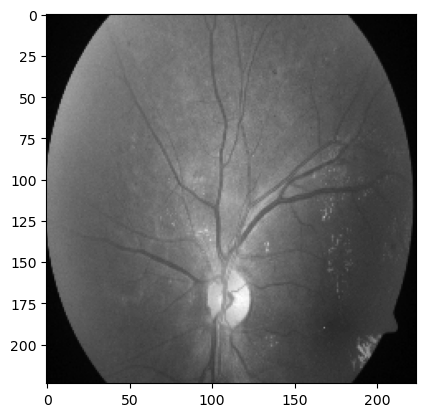

In [3]:
image = cv2.imread('ATEST_images/1_Mild/03e25101e8e8.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#image=cv2.addWeighted ( image, 0 , cv2.GaussianBlur( image , (0 ,0 ) , 10) ,-4 ,128)
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

plt.imshow(image, cmap='gray')

224 224


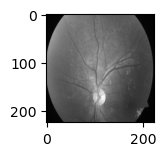

In [25]:
dpi = 80 #inch

# path=f"../input/aptos2019-blindness-detection/train_images/5c7ab966a3ee.png" # notice upper part
path=f"ATEST_images/1_Mild/03e25101e8e8.png" # lower-right, this still looks not so severe, can be class3
image = cv2.imread(path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
height, width = image.shape
print(height, width)

SCALE=2
figsize = (width / float(dpi))/SCALE, (height / float(dpi))/SCALE

fig = plt.figure(figsize=figsize)
plt.imshow(image, cmap='gray')

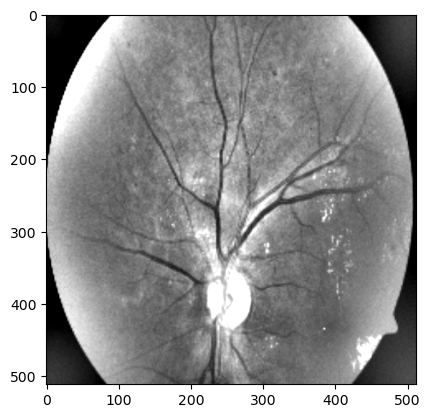

In [27]:
path=f"ATEST_images/1_Mild/03e25101e8e8.png"
image = cv2.imread(path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
image=cv2.addWeighted ( image,4, cv2.GaussianBlur( image , (0,0) , IMG_SIZE/10) ,-4 ,128) # the trick is to add this line

plt.imshow(image, cmap='gray')

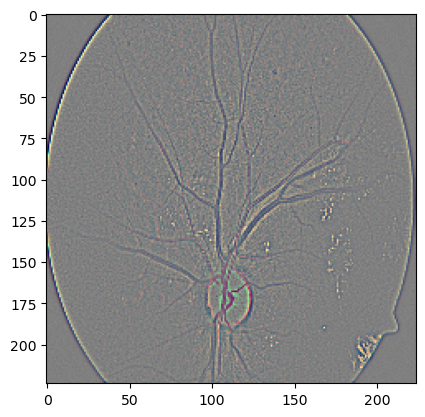

In [52]:
path=f"ATEST_images/1_Mild/03e25101e8e8.png"
image = load_ben_color(path,sigmaX=1)

plt.imshow(image)

224 224


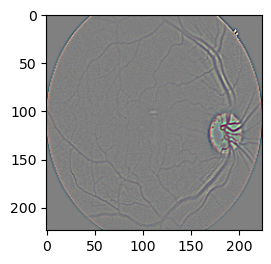

In [21]:
dpi = 80 #inch

# path=f"../input/aptos2019-blindness-detection/train_images/5c7ab966a3ee.png" # notice upper part
path=f"ATEST_images/0_No_DR/0b64a0a06f9a.png" # lower-right, can be class3
image = load_ben_color(path,sigmaX=1)

height, width = IMG_SIZE, IMG_SIZE
print(height, width)

SCALE=1
figsize = (width / float(dpi))/SCALE, (height / float(dpi))/SCALE

fig = plt.figure(figsize=figsize)
plt.imshow(image, cmap='gray')

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt


def predict_class1(path):
    image = load_ben_color(path,sigmaX=1)
    
    plt.imshow(image)
    image = np.array(image) / 255.0
    new_model = tf.keras.models.load_model("exemple1_model.h5")
    predict=new_model.predict(np.array([image]))
    per=np.argmax(predict,axis=1)
    print(per)
    print(predict)

    arr = np.array(predict)
    val1 = arr[0][0]
    val2 = arr[0][1]
    if val1 < val2:
        print('No DR')
    else:
        print('DR')

AttributeError: 'int' object has no attribute 'predict'

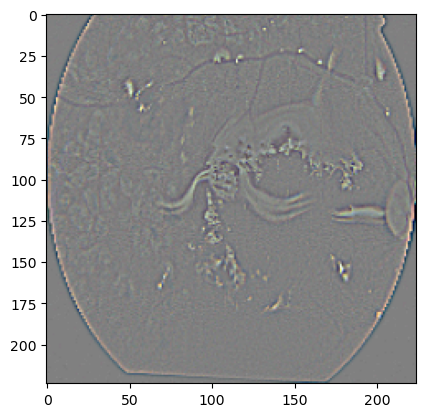

In [17]:
predict_class1('ATEST_images/4_Proliferate_DR/2fde69f20585.png')

In [57]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt


def predict_class2(path):
    image = load_ben_color(path,sigmaX=1)
    
    plt.imshow(image)
    image = np.array(image) / 255.0
    new_model = tf.keras.models.load_model("exemple5_model.h5")
    predict=new_model.predict(np.array([image]))
    per=np.argmax(predict,axis=1)
    print(per)
    print(predict)

    arr = np.array(predict)
    val1 = arr[0][0]
    val2 = arr[0][1] 
    val3 = arr[0][2]
    val4 = arr[0][3] 
    val5 = arr[0][4]
    
    print(f'No_DR: {round(val1 * 100, 2)}% \nMild: {round(val2 * 100, 2)}% \nModerate: {round(val3 * 100, 2)}% \nSevere: {round(val4 * 100, 2)}% \nProliferate: {round(val5 * 100, 2)}%')
    
    if np.max(arr) == val1 :
        print('No DR')
    elif np.max(arr) == val2 :
        print('Mild')
    elif np.max(arr) == val3 :
        print('Moderate')
    elif np.max(arr) == val4 :
        print('Severe')
    elif np.max(arr) == val5 :
        print('Proliferate')

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
[3]
[[0.00220485 0.02380553 0.20238711 0.45606124 0.31554127]]
No_DR: 0.22% 
Mild: 2.38% 
Moderate: 20.24% 
Severe: 45.61% 
Proliferate: 31.55%
Severe


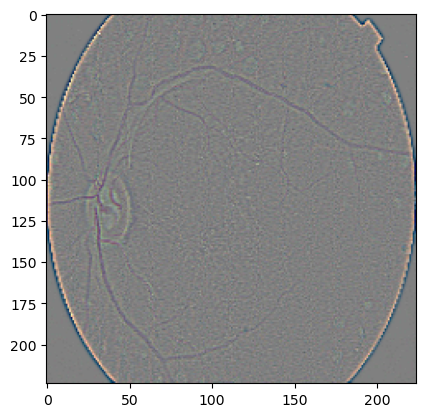

In [59]:
predict_class2('ATEST_images/4_Proliferate_DR/2f284b6a1940.png')